<a href="https://colab.research.google.com/github/z1nd3/ML/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Итоговый вывод

В ходе работы был проведён исследовательский анализ данных, выполнено создание новых признаков, обучены и сравнены несколько моделей машинного обучения. Анализ показал, что наиболее важными факторами выживания являются пол пассажира, класс, стоимость билета и некоторые производные признаки. По результатам 5-fold cross-validation лучшей моделью оказался `GradientBoosting`.

## Сравнение моделей

В рамках работы были протестированы модели из разных семейств: линейная модель, дерево решений, ансамблевые методы и нейронная сеть. По результатам 5-fold cross-validation лучшей моделью оказался `GradientBoosting`, показавший наивысшую среднюю accuracy 0.8316.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(32,16), max_iter=1500, random_state=42)
}

results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    results.append((name, scores.mean(), scores.std()))

for name, mean_score, std_score in results:
    print(f'{name}: mean={mean_score:.4f}, std={std_score:.4f}')

LogisticRegression: mean=0.8014, std=0.0176
DecisionTree: mean=0.8103, std=0.0151
RandomForest: mean=0.8260, std=0.0151
GradientBoosting: mean=0.8316, std=0.0159
MLP: mean=0.8227, std=0.0180


## Feature Importances

Анализ важности признаков показал, что наибольший вклад в предсказание выживания вносят `Fare`, `Age`, `Sex` и `Pclass`. Это подтверждает результаты EDA и показывает, что модель использует наиболее информативные признаки.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(15))

            Feature  Importance
4         num__Fare    0.252940
1          num__Age    0.235547
8     cat__Sex_male    0.143562
7   cat__Sex_female    0.142013
0       num__Pclass    0.084500
5   num__FamilySize    0.045822
2        num__SibSp    0.025237
3        num__Parch    0.023833
11  cat__Embarked_S    0.016082
6      num__IsAlone    0.012404
9   cat__Embarked_C    0.011735
10  cat__Embarked_Q    0.006325


## Простая модель

В качестве базовой модели была использована Logistic Regression. Модель показала accuracy около 0.80, что можно считать хорошим базовым результатом. При этом модель лучше распознаёт невыживших пассажиров, чем выживших.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
X = df[features]
y = df['Survived']

numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
categorical_features = ['Sex', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## Корреляция новых признаков с таргетом

Анализ новых признаков показал, что `IsAlone` имеет более выраженную связь с выживанием, чем `FamilySize`. Это позволяет предположить, что сам факт одиночной поездки был важнее, чем общее количество родственников на борту.

In [ ]:
new_features_corr = df[['Survived', 'FamilySize', 'IsAlone']].corr()
print(new_features_corr['Survived'].sort_values(ascending=False))

Survived      1.000000
FamilySize    0.016639
IsAlone      -0.203367
Name: Survived, dtype: float64


## Is Alone
Также был создан бинарный признак `IsAlone`, показывающий, ехал ли пассажир один. Этот признак помогает компактно учесть влияние одиночной поездки на вероятность выживания.

In [ ]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df[['FamilySize', 'IsAlone']].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


## Feature Engineering

Был создан новый признак `FamilySize`, отражающий общий размер семьи пассажира на борту. Он объединяет информацию из `SibSp` и `Parch` и может быть более информативным для модели, чем исходные признаки по отдельности.

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


## Корреляция числовых признаков с таргетом

Корреляционный анализ показал, что среди числовых признаков наиболее заметная связь с выживанием наблюдается у `Pclass` и `Fare`. Признак `Pclass` имеет отрицательную корреляцию, а `Fare` — положительную, что соответствует результатам визуального анализа.

In [ ]:
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
corr = numeric_df.corr()
print(corr['Survived'].sort_values(ascending=False))

Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Pclass     -0.338481
Name: Survived, dtype: float64


## Стоимость билета и выживание

Из графика видно, что у выживших пассажиров стоимость билета в среднем выше, чем у невыживших. Это позволяет сделать вывод, что признак `Fare` положительно связан с вероятностью выживания.

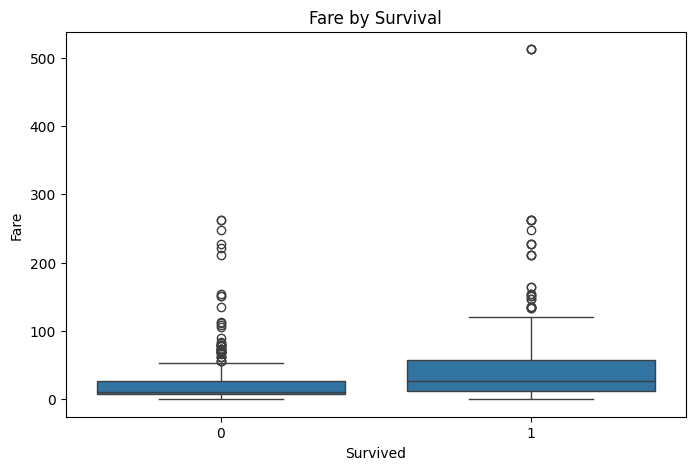

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare by Survival')
plt.show()

## Возраст и выживание

Boxplot показывает, что распределения возраста у выживших и невыживших пассажиров во многом пересекаются. Это означает, что возраст влияет на вероятность выживания, но его влияние выражено слабее, чем у пола и класса пассажира.

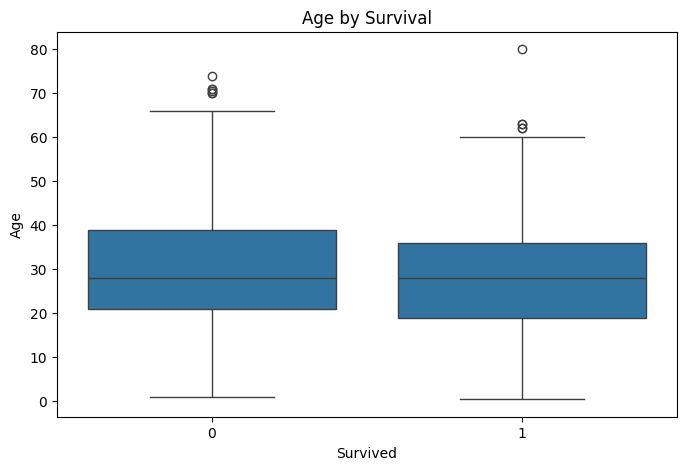

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age by Survival')
plt.show()

## Распределение возраста

Распределение возраста показывает, что большинство пассажиров находились в диапазоне от 20 до 40 лет, с пиком примерно в районе 20–30 лет. Также важно учитывать, что в признаке `Age` имеются пропуски, которые нужно обработать перед обучением моделей.

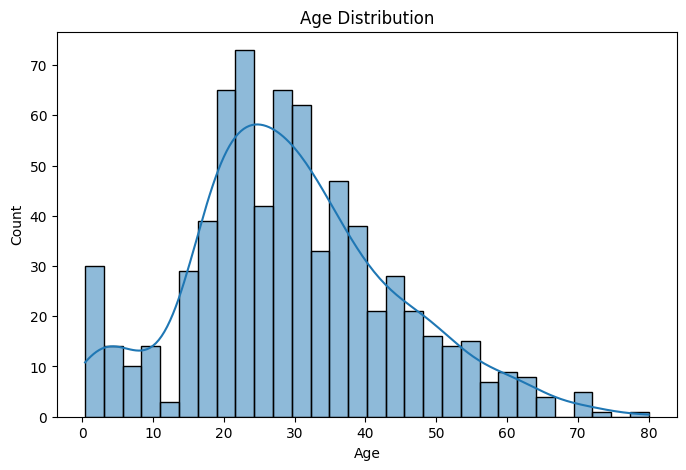

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

## Выживаемость по классу пассажира

График показывает, что пассажиры 1 класса выживали чаще, тогда как среди пассажиров 3 класса погибших было значительно больше. Это указывает на сильную связь между признаком `Pclass` и вероятностью выживания.

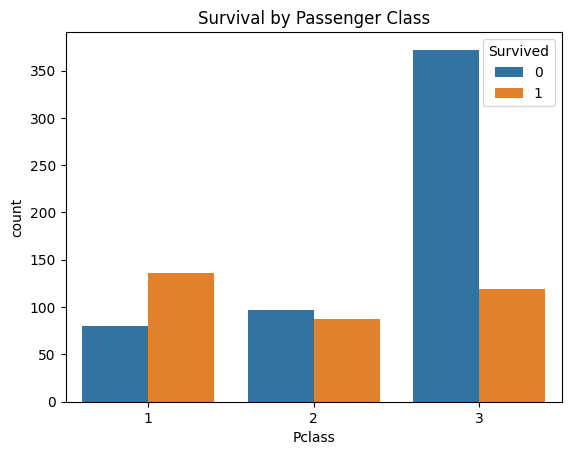

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

## Выживаемость по полу

Из графика видно, что женщины выживали значительно чаще мужчин. Следовательно, признак `Sex` является одним из наиболее важных факторов, влияющих на вероятность выживания пассажира.

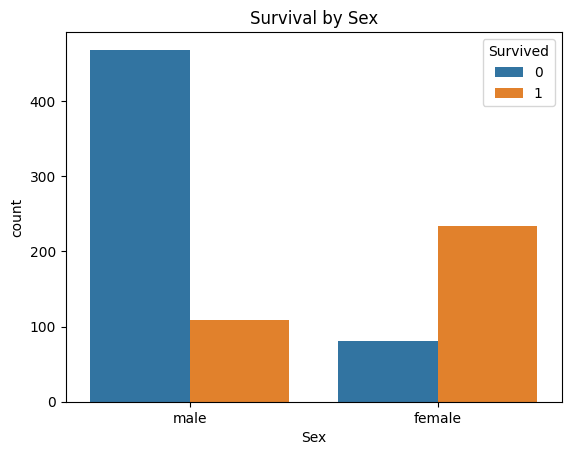

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Sex')
plt.show()

## Распределение целевой переменной

График показывает, что в датасете погибших пассажиров больше, чем выживших. Это означает, что классы слегка несбалансированы, поэтому при анализе моделей важно учитывать не только accuracy, но и другие метрики качества.

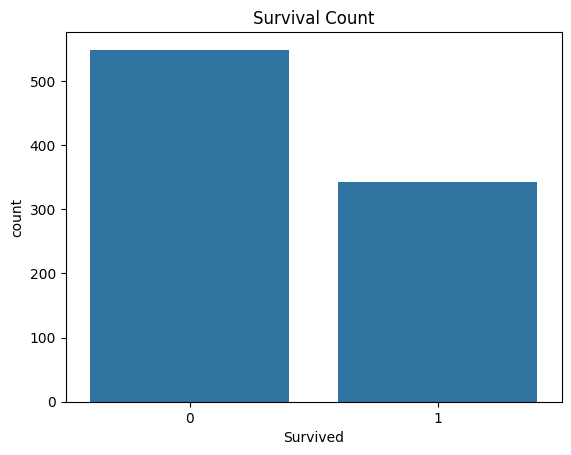

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

## Общая информация о датасете

Датасет содержит 891 строку и 12 столбцов. В данных присутствуют как числовые, так и категориальные признаки. Основные пропуски наблюдаются в колонках `Age`, `Cabin` и `Embarked`, поэтому на этапе подготовки данных их необходимо учитывать. Средний возраст пассажиров составляет около 29.7 лет, а средняя стоимость билета — около 32.2.

In [ ]:
print("Размер таблицы:", df.shape)
print("\nКолонки:")
print(df.columns)

print("\nИнформация о данных:")
print(df.info())

print("\nПропуски:")
print(df.isnull().sum())

print("\nСтатистика:")
print(df.describe())

Размер таблицы: (891, 12)

Колонки:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Пропуски:
PassengerId      

## Загрузка данных

Датасет Titanic загружен. По первым строкам видно, что каждая строка соответствует одному пассажиру, а столбцы содержат информацию о его характеристиках. Целевая переменная задачи — `Survived`, где 1 означает, что пассажир выжил, а 0 — что нет.

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
